In [106]:
import pandas as pd
import numpy as np
import os

# ---------------------------------------------------------
# Step 0: Data Import and Cleaning
# ---------------------------------------------------------

# 1. File Path Configuration
file_path = os.path.expanduser('UK_IO_Table.xlsx')

# 2. Load IO Table Data
# Loading the 'IO_Table' sheet directly, setting the first column as the index
df = pd.read_excel(file_path, sheet_name='IO_Table', header=0, index_col=0)

print(f"📂 Loaded 'IO_Table' successfully.")
print(f"   - Original Shape: {df.shape}")

# 3. Data Cleaning and Matrix Construction
# Ensure all data is numeric and fill NaNs with 0
matrix_df = df.apply(pd.to_numeric, errors='coerce').fillna(0)

# Define Adjacency Matrix A (No transpose needed as per analysis)
A = matrix_df

# ---------------------------------------------------------
# Verification
# ---------------------------------------------------------
print("-" * 50)
print(f"🔹 Final Matrix A Shape: {A.shape}") # Should be (104, 104)
print(f"🔹 Data Type: {A.dtypes.iloc[0]}")  # Should be float64
print("-" * 50)

print("🔹 Diagonal Elements (Self-loops) for Top 3 Industries:")
for i in range(3):
    print(f"   {A.index[i]} -> {A.columns[i]}: {A.iloc[i, i]:.4f}")

print("-" * 50)
print("✅ Matrix A is ready for analysis.")


📂 Loaded 'IO_Table' successfully.
   - Original Shape: (104, 104)
--------------------------------------------------
🔹 Final Matrix A Shape: (104, 104)
🔹 Data Type: float64
--------------------------------------------------
🔹 Diagonal Elements (Self-loops) for Top 3 Industries:
   A01 -> A01: 0.1569
   A02 -> A02: 0.1859
   A03 -> A03: 0.0000
--------------------------------------------------
✅ Matrix A is ready for analysis.


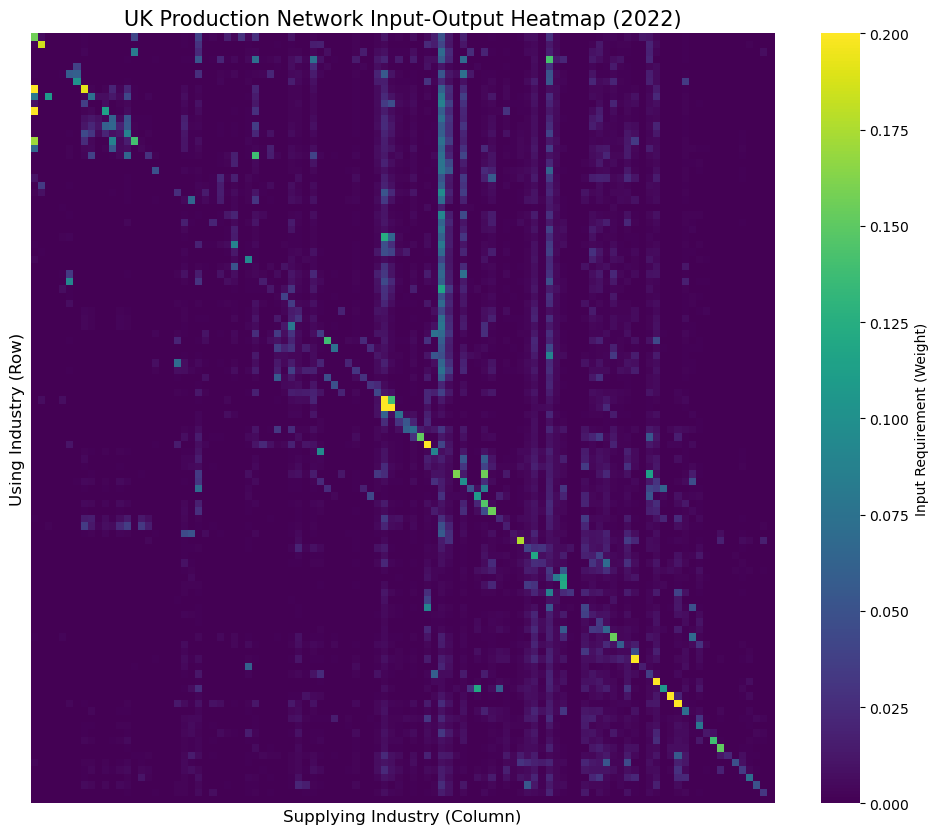

🔹 Sparsification Complete (Threshold = 0.05)
   - Original Edges: 10492
   - Retained Edges: 156


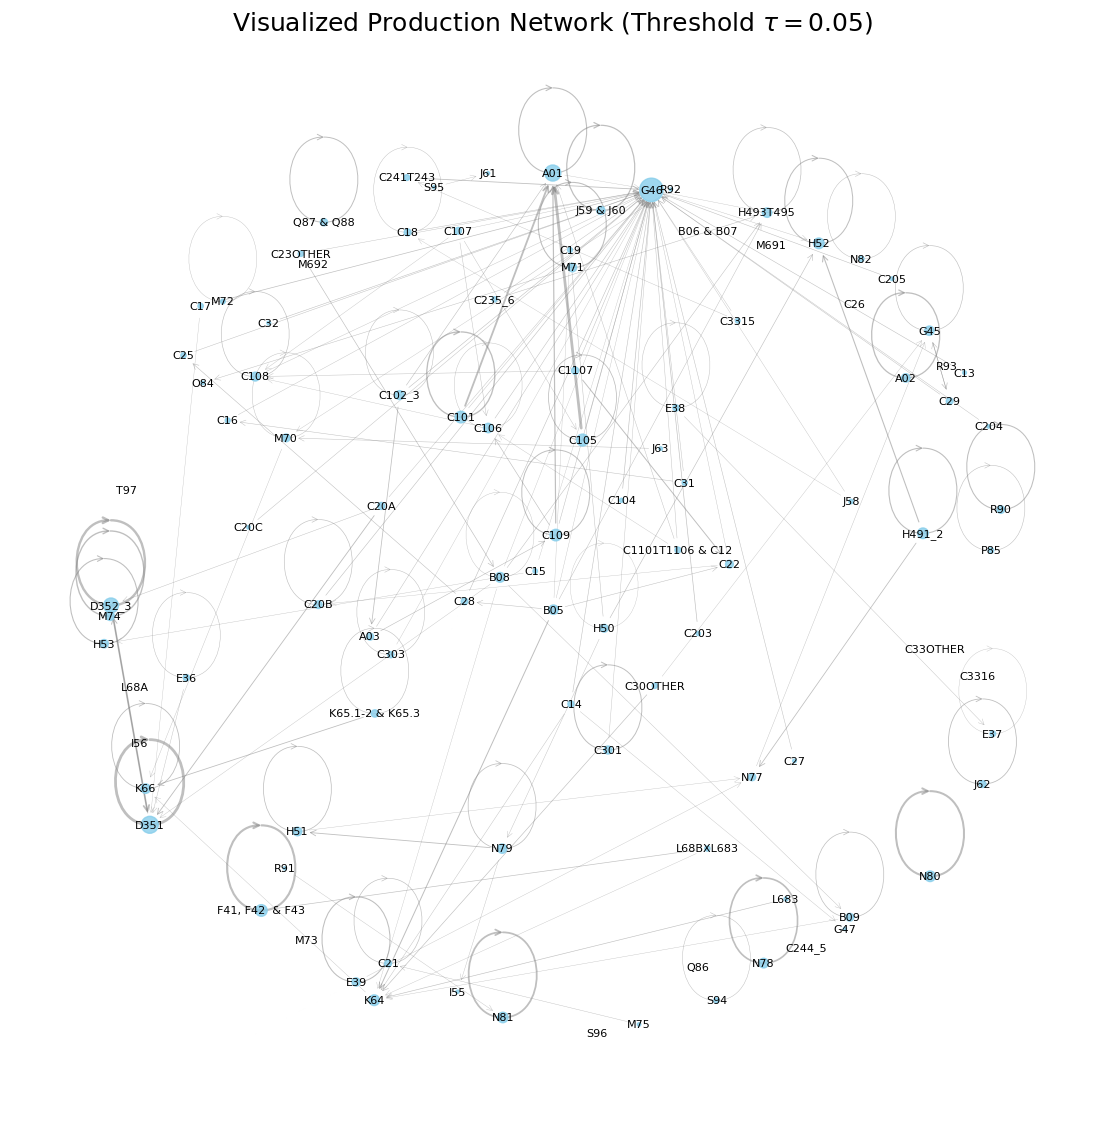

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import random
import numpy as np

# ---------------------------------------------------------
# Global Random Seed Configuration
# ---------------------------------------------------------
MY_SEED = 42
np.random.seed(MY_SEED)
random.seed(MY_SEED)

# ---------------------------------------------------------
# Task 1(b): Visualization of IO Table (Heatmap)
# ---------------------------------------------------------
plt.figure(figsize=(12, 10))

# Vmax set to 0.2 to enhance visibility of lower weights
sns.heatmap(A, cmap='viridis', vmax=0.2, cbar_kws={'label': 'Input Requirement (Weight)'})

plt.title("UK Production Network Input-Output Heatmap (2022)", fontsize=15)

# Axis labels 
plt.ylabel("Using Industry (Row)", fontsize=12)
plt.xlabel("Supplying Industry (Column)", fontsize=12)

plt.xticks([]) 
plt.yticks([]) 
plt.show()

# ---------------------------------------------------------
# Task 1(c): Sparsification (Pruning Weak Links)
# ---------------------------------------------------------
tau = 0.05 
B = A.copy()
B[B < tau] = 0

print(f"🔹 Sparsification Complete (Threshold = {tau})")
print(f"   - Original Edges: {(A > 0).sum().sum()}")
print(f"   - Retained Edges: {(B > 0).sum().sum()}")

# ---------------------------------------------------------
# Task 1(d): Network Graph Visualization (Directed Weighted Graph)
# ---------------------------------------------------------
G = nx.from_pandas_adjacency(B, create_using=nx.DiGraph)

# Node size based on total degree (sum of weights)
degrees = dict(G.degree(weight='weight'))
node_sizes = [v * 100 for v in degrees.values()] 

plt.figure(figsize=(14, 14))

# Layout: Spring layout for aesthetically pleasing clustering
pos = nx.spring_layout(G, k=0.3, iterations=50, seed=MY_SEED)

# Draw Nodes
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.8)

# Draw Edges (Width proportional to weight)
weights = [G[u][v]['weight'] for u,v in G.edges()]
nx.draw_networkx_edges(G, pos, width=[w * 5 for w in weights], 
                       arrowstyle='->', arrowsize=10, edge_color='gray', alpha=0.5)

# Draw Labels
nx.draw_networkx_labels(G, pos, font_size=8, font_family='sans-serif')

plt.title(f"Visualized Production Network (Threshold $\\tau={tau}$)", fontsize=18)
plt.axis('off') 
plt.show()


In [108]:
import pandas as pd
import numpy as np
import networkx as nx

# ---------------------------------------------------------
# Task 2: Computation of Network Statistics
# ---------------------------------------------------------

# 1. Weighted In-degree (Upstream Input Dependence)
# Summing across columns (axis=1) gives total inputs purchased by the row sector
in_degree = A.sum(axis=1)

# 2. Weighted Out-degree (Downstream Supplier Importance)
# Summing across rows (axis=0) gives total supplies provided by the column sector
out_degree = A.sum(axis=0)

# 3. Eigenvector Centrality (Influence)
# Create a directed graph from the adjacency matrix
G_full = nx.from_pandas_adjacency(A, create_using=nx.DiGraph)

try:
    # Compute eigenvector centrality
    # max_iter: Increased to 10,000 to ensure convergence
    # tol: Tolerance level for convergence
    eigen_centrality = nx.eigenvector_centrality(G_full, weight='weight', max_iter=10000, tol=1e-06)
except nx.PowerIterationFailedConvergence:
    print("⚠️ Warning: Power iteration failed to converge. Increase max_iter.")
    eigen_centrality = {} 

# Convert dictionary to Series
eigen_series = pd.Series(eigen_centrality)

# ---------------------------------------------------------
# Aggregation and Comparison of Top 5 Industries
# ---------------------------------------------------------

# Combine all statistics into a single DataFrame
stats_df = pd.DataFrame({
    'In-Degree (Input Use)': in_degree,
    'Out-Degree (Supplier)': out_degree,
    'Eigenvector (Hub)': eigen_series
})

# Function to extract top 5 industries for a given metric
def get_top_5(df, col):
    return df[col].sort_values(ascending=False).head(5).index.tolist()

# Get top 5 lists
top_in = get_top_5(stats_df, 'In-Degree (Input Use)')
top_out = get_top_5(stats_df, 'Out-Degree (Supplier)')
top_eigen = get_top_5(stats_df, 'Eigenvector (Hub)')

# Print the comparison table
print("-" * 95)
print(f"📊 Top 5 Industries by Network Centrality Measures")
print("-" * 95)
print(f"{'Rank':<5} | {'In-Degree (Top Consumers)':<28} | {'Out-Degree (Top Suppliers)':<28} | {'Eigenvector (Key Hubs)':<25}")
print("-" * 95)

for i in range(5):
    print(f"{i+1:<5} | {top_in[i]:<28} | {top_out[i]:<28} | {top_eigen[i]:<25}")

print("-" * 95)


-----------------------------------------------------------------------------------------------
📊 Top 5 Industries by Network Centrality Measures
-----------------------------------------------------------------------------------------------
Rank  | In-Degree (Top Consumers)    | Out-Degree (Top Suppliers)   | Eigenvector (Key Hubs)   
-----------------------------------------------------------------------------------------------
1     | C105                         | G46                          | D351                     
2     | C101                         | K64                          | D352_3                   
3     | B05                          | D351                         | F41, F42  & F43          
4     | H491_2                       | H493T495                     | G46                      
5     | C109                         | G47                          | M70                      
--------------------------------------------------------------------------------------

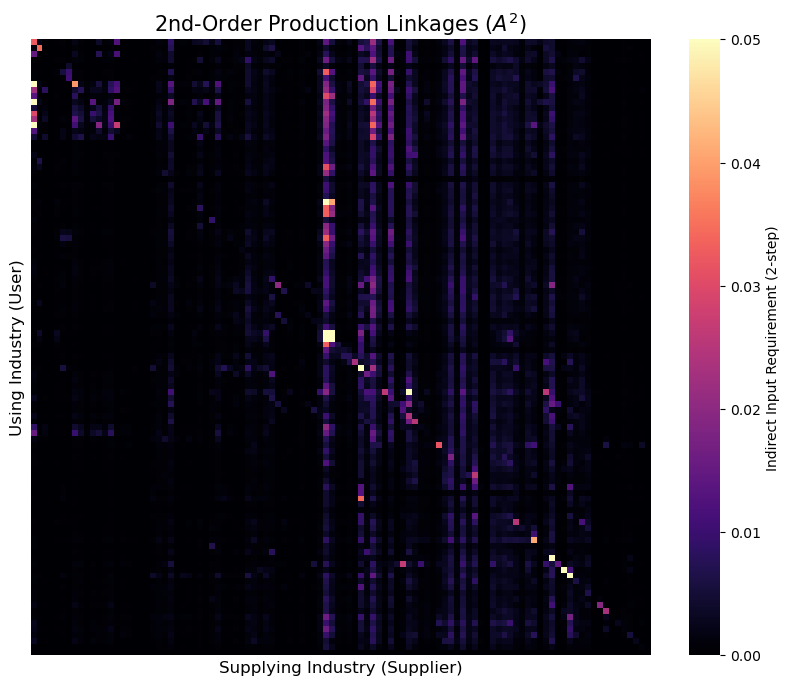

🔹 Threshold for Distance Calculation: 0.05
   - Number of retained edges: 156

 Industries with Shortest Average Path Length (Central Suppliers):
S95                1.0
K65.1-2 & K65.3    1.0
G46                1.0
E38                1.0
D352_3             1.0
dtype: float64

 Industries with Longest Average Path Length (Peripheral Suppliers):
N77    2.800000
H50    3.200000
H51    3.333333
E39    3.333333
N79    3.500000
dtype: float64


In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import numpy as np
import pandas as pd


# Task 3: Production Network Diffusion Analysis



# Part 1: Matrix Powers and Visualization (Task 3a, 3b)


# Compute A^2 to capture 2nd-order indirect linkages
A_mat = A.to_numpy()
A2 = np.linalg.matrix_power(A_mat, 2)

# Visualization: Heatmap of 2nd-Order Linkages (A^2)
plt.figure(figsize=(10, 8))
# Vmax is set lower (0.05) to highlight the structure of indirect connections
sns.heatmap(A2, cmap='magma', vmax=0.05, cbar_kws={'label': 'Indirect Input Requirement (2-step)'})

plt.title("2nd-Order Production Linkages ($A^2$)", fontsize=15)
plt.ylabel("Using Industry (User)", fontsize=12)
plt.xlabel("Supplying Industry (Supplier)", fontsize=12)
plt.xticks([])
plt.yticks([])
plt.show()


# Part 2: Shortest Path Analysis (Task 3c)


# Set threshold for distance calculation
# Consistent with Phase 1 to focus on strong structural ties
tau_phase3 = 0.05 

# Generate sparsified matrix B for distance calculation
B_dist = A.copy()
B_dist[B_dist < tau_phase3] = 0

print(f"🔹 Threshold for Distance Calculation: {tau_phase3}")
print(f"   - Number of retained edges: {(B_dist > 0).sum().sum()}")

# Create Directed Graph from sparsified matrix B
G_dist = nx.from_pandas_adjacency(B_dist, create_using=nx.DiGraph)

try:
    # Compute all-pairs shortest path lengths (Unweighted distance)
    # This measures how many steps (links) it takes to reach other industries
    path_lengths = dict(nx.all_pairs_shortest_path_length(G_dist))

    # Calculate average shortest path length for each node
    avg_distances = {}
    for node in path_lengths:
        dists = list(path_lengths[node].values())
        
        # Exclude self-loops (distance 0) and compute mean of reachable nodes
        valid_dists = [d for d in dists if d > 0]
        
        if valid_dists:
            avg_distances[node] = np.mean(valid_dists)
        else:
            # Handle isolated nodes (cannot reach any other node)
            avg_distances[node] = np.nan 

    # Sort results to identify central and peripheral industries
    dist_series = pd.Series(avg_distances).dropna().sort_values()

    print("\n Industries with Shortest Average Path Length (Central Suppliers):")
    print(dist_series.head(5))

    print("\n Industries with Longest Average Path Length (Peripheral Suppliers):")
    print(dist_series.tail(5))

except Exception as e:
    print(f"❌ Error during calculation: {e}")


 Starting Simulation: G46 vs N79


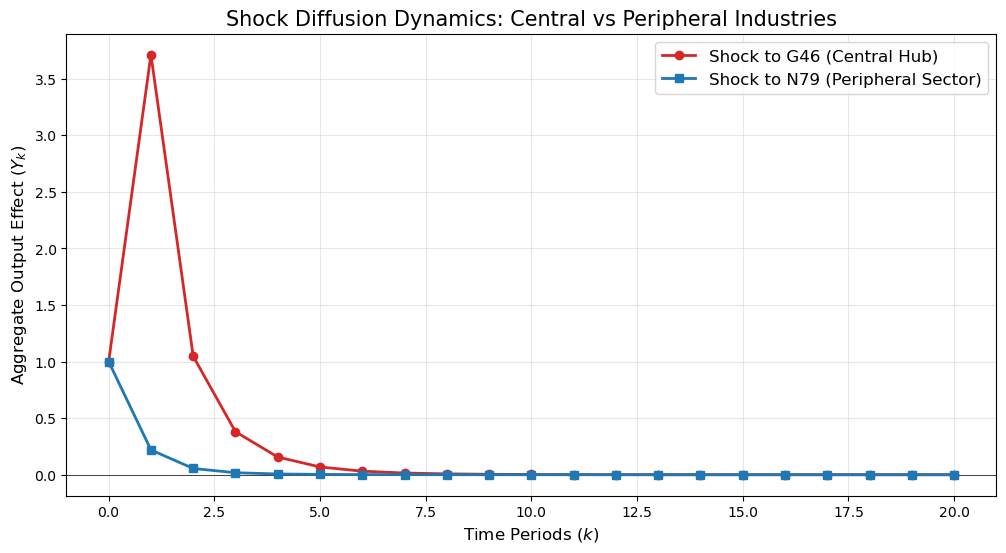

----------------------------------------------------------------------
📊 Simulation Results Summary (Cumulative Economic Multipliers):
----------------------------------------------------------------------
1. Target Industry: G46 (Central Hub - Wholesale Trade)
   - Cumulative Equilibrium Output (Y*): 6.4253
   - Economic Interpretation: A £1 unit shock to the Wholesale sector
     generates a total expansion of £6.43 in the overall economy.
----------------------------------------------------------------------
2. Target Industry: N79 (Peripheral Sector - Travel Agency)
   - Cumulative Equilibrium Output (Y*): 1.3035
   - Economic Interpretation: A £1 unit shock to the Travel Agency sector
     generates a total expansion of only £1.30 in the overall economy.
----------------------------------------------------------------------
Conclusion: Shocks to central hubs propagate more intensely and create
significantly larger aggregate multipliers compared to peripheral sectors.
-------------

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg


# Task 4: Shock Simulation

def simulate_shock(target_industry_code, A_matrix, steps=20):
    """
    Simulates the diffusion of a unit shock (1.0) to a specific industry.
    Returns the time path of aggregate output and the long-run equilibrium multiplier.
    """
    N = A_matrix.shape[0]
    
    # 1. Create shock vector epsilon
    epsilon = np.zeros(N)
    
    if target_industry_code not in A_matrix.index:
        print(f"Error: Industry code {target_industry_code} not found.")
        return None, None
        
    target_idx = A_matrix.index.get_loc(target_industry_code)
    epsilon[target_idx] = 1.0
    
    # 2. Dynamic Simulation (y^(k) = A^k * epsilon)
    # Calculate the aggregate output effect (sum of y^(k)) at each period k
    
    current_vec = epsilon.copy()
    agg_output_path = [] # List to store Y_k
    
    # k=0 (Immediate impact)
    agg_output_path.append(np.sum(current_vec)) 
    
    A_numpy = A_matrix.to_numpy()
    
    # k=1 to 20
    for k in range(1, steps + 1):
        next_vec = A_numpy @ current_vec # Next period effect
        agg_output = np.sum(next_vec)
        agg_output_path.append(agg_output)
        current_vec = next_vec # Update vector
        
    # 3. Equilibrium Calculation: y* = (I - A)^-1 * epsilon
    # Using linear solver instead of matrix inversion (as per hint)
    I = np.eye(N)
    y_star = np.linalg.solve(I - A_numpy, epsilon)
    Y_star_aggregate = np.sum(y_star) # Total Cumulative Multiplier
    
    return agg_output_path, Y_star_aggregate


# Execution & Comparison: Central (G46) vs Peripheral (N79)

target_hub = 'G46'  # Wholesale Trade (Central Hub)
target_periph = 'N79' # Travel Agency (Peripheral Sector)

print(f" Starting Simulation: {target_hub} vs {target_periph}")

path_hub, eq_hub = simulate_shock(target_hub, A, steps=20)
path_periph, eq_periph = simulate_shock(target_periph, A, steps=20)


# Task 4(d): Plotting the Impulse Response Functions

plt.figure(figsize=(12, 6))
periods = range(21)

# 1. Hub (G46) Plot
plt.plot(periods, path_hub, 'o-', label=f'Shock to {target_hub} (Central Hub)', color='#d62728', linewidth=2)
plt.axhline(y=0, color='black', linewidth=0.5)

# 2. Peripheral (N79) Plot
plt.plot(periods, path_periph, 's-', label=f'Shock to {target_periph} (Peripheral Sector)', color='#1f77b4', linewidth=2)

plt.title("Shock Diffusion Dynamics: Central vs Peripheral Industries", fontsize=15)
plt.xlabel("Time Periods ($k$)", fontsize=12)
plt.ylabel("Aggregate Output Effect ($Y_k$)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()


# Output Results (Formatted for Report)

print("-" * 70)
print(f"📊 Simulation Results Summary (Cumulative Economic Multipliers):")
print("-" * 70)

print(f"1. Target Industry: {target_hub} (Central Hub - Wholesale Trade)")
print(f"   - Cumulative Equilibrium Output (Y*): {eq_hub:.4f}")
print(f"   - Economic Interpretation: A £1 unit shock to the Wholesale sector")
print(f"     generates a total expansion of £{eq_hub:.2f} in the overall economy.")

print("-" * 70)

print(f"2. Target Industry: {target_periph} (Peripheral Sector - Travel Agency)")
print(f"   - Cumulative Equilibrium Output (Y*): {eq_periph:.4f}")
print(f"   - Economic Interpretation: A £1 unit shock to the Travel Agency sector")
print(f"     generates a total expansion of only £{eq_periph:.2f} in the overall economy.")

print("-" * 70)
print("Conclusion: Shocks to central hubs propagate more intensely and create")
print("significantly larger aggregate multipliers compared to peripheral sectors.")
print("-" * 70)
